# **ИМПОРТ БИБЛИОТЕК**

In [ ]:

# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

# Настройка вывода графиков прямо в ноутбуке
%matplotlib inline

# **УТИЛИТЫ**

In [ ]:

def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'ЭПОХА: {epoch+1}, loss: {logs["loss"]}')
    print('________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    plt.figure(dpi=100)

    # Предсказание енкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0], predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение
    plt.show()

# Создание экземпляра коллбэка
ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

def clean():
    # Получение названий всех картинок
    paths = glob.glob('*.jpg')

    # Удаление всех картинок по полученным путям
    for p in paths:
        os.remove(p)

# Очистка директории перед запуском
clean()

# **ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ**

In [ ]:

# Загрузка оригинального датасета MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Нормировка и решейп под требования свёрточных слоев (добавление канала)
X_train = X_train.astype('float32') / 255.
X_train = X_train.reshape(-1, 28, 28, 1)

# Выбор визуализируемых классов (цифр 0, 1 и 3) и формирование подвыборок по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

print(f"Размер отфильтрованной обучающей выборки: {X_train.shape}")

Размер отфильтрованной обучающей выборки: (18796, 28, 28, 1)


# **АРХИТЕКТУРА И ПАРАМЕТРЫ МОДЕЛИ**

In [ ]:

#  Архитектура Энкодера (Сжатие)
encoder_input = Input(shape=(28, 28, 1), name="Encoder_Input")

x = Conv2D(32, (3, 3), padding='same', activation='relu')(encoder_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)  # Изменение размера до 14x14

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)  # Изменение размера до 7x7

x = Flatten()(x)
x = Dense(64, activation='relu')(x)

# Узкое горлышко (Bottleneck) — ровно 2 нейрона линейной активации для 2D-карты
latent_output = Dense(2, activation='linear', name="Bottleneck_2D")(x)

# Сборка модели Энкодера (обязательно имя переменной 'encoder' для работы коллбэка)
encoder = Model(encoder_input, latent_output, name="Encoder")


# Архитектура Декодера (Восстановление)
decoder_input = Input(shape=(2,), name="Decoder_Input")

x = Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)  # Восстановление до 14x14
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)  # Восстановление до 28x28
x = BatchNormalization()(x)

# Выходной слой свертки с функцией активации sigmoid для масштаба пикселей [0, 1]
decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name="Decoder_Output")(x)

# Сборка модели Декодера
decoder = Model(decoder_input, decoder_output, name="Decoder")


# Сборка Полного Автокодировщика
autoencoder_input = Input(shape=(28, 28, 1))
latent_representation = encoder(autoencoder_input)
autoencoder_output = decoder(latent_representation)

autoencoder = Model(autoencoder_input, autoencoder_output, name="Full_Autoencoder")

# Компиляция: Оптимизатор Adam с жестко заданной скоростью обучения 0.001 и функцией потерь MSE
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# **ЗАПУСК ОБУЧЕНИЯ И ПРОВЕРКА РЕЗУЛЬТАТОВ**

Старт обучения свёрточного автокодировщика...
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1180________________________
*** ЭПОХА: 1, loss: 0.07733391225337982 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


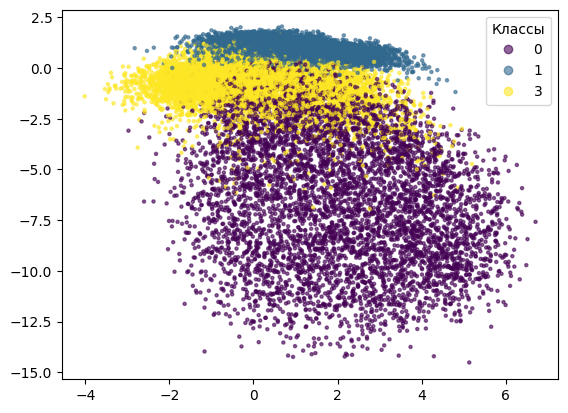

147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - loss: 0.0773
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0423________________________
*** ЭПОХА: 2, loss: 0.03935578837990761 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


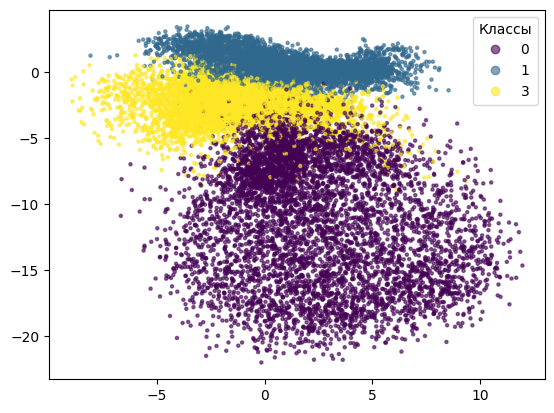

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0394
Epoch 3/10
143/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0337________________________
*** ЭПОХА: 3, loss: 0.03335949033498764 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


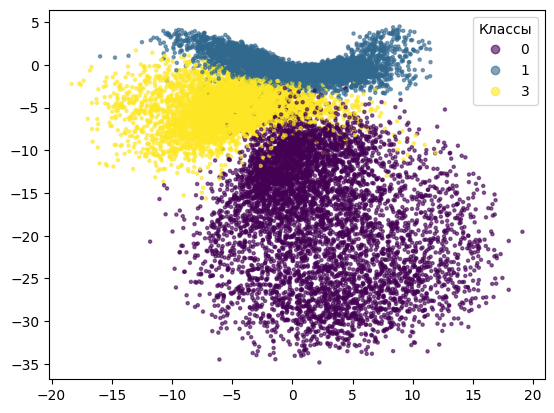

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0334
Epoch 4/10
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0315________________________
*** ЭПОХА: 4, loss: 0.031371746212244034 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


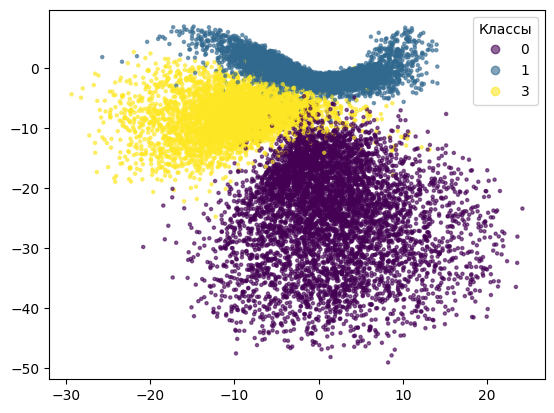

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0314
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0304________________________
*** ЭПОХА: 5, loss: 0.030400749295949936 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


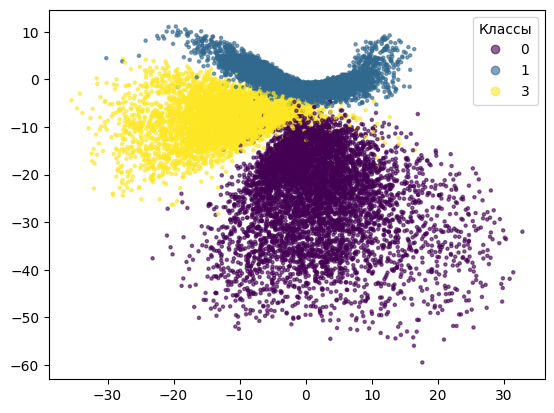

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0304
Epoch 6/10
144/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0299________________________
*** ЭПОХА: 6, loss: 0.029828425496816635 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


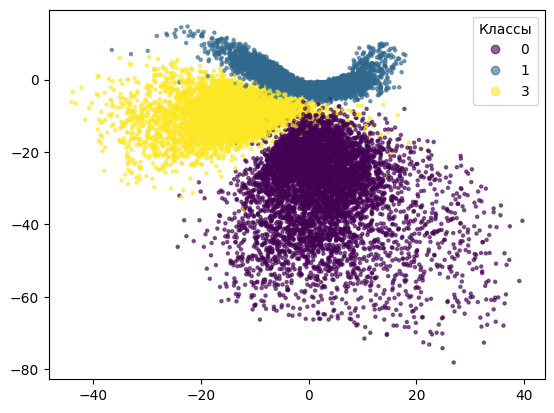

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0298
Epoch 7/10
144/147 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0293________________________
*** ЭПОХА: 7, loss: 0.029425660148262978 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


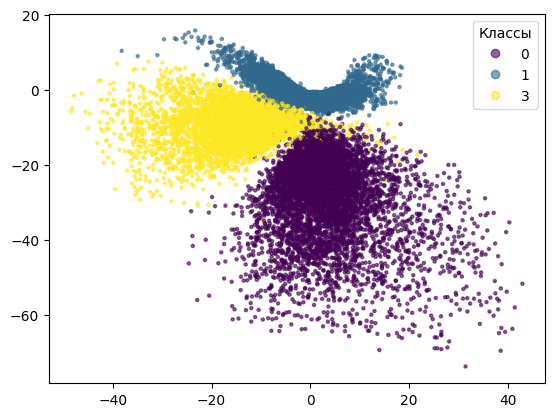

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0294
Epoch 8/10
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0293________________________
*** ЭПОХА: 8, loss: 0.029211528599262238 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


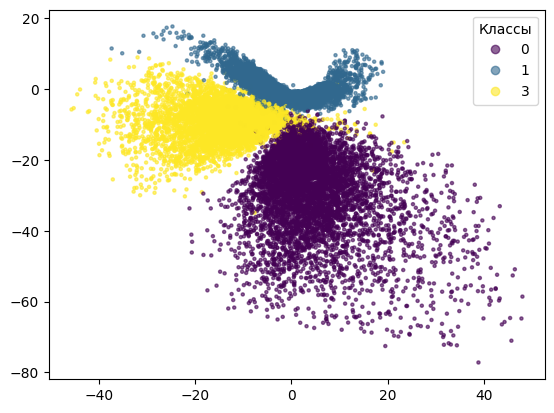

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0292
Epoch 9/10
143/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0286________________________
*** ЭПОХА: 9, loss: 0.02875175140798092 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


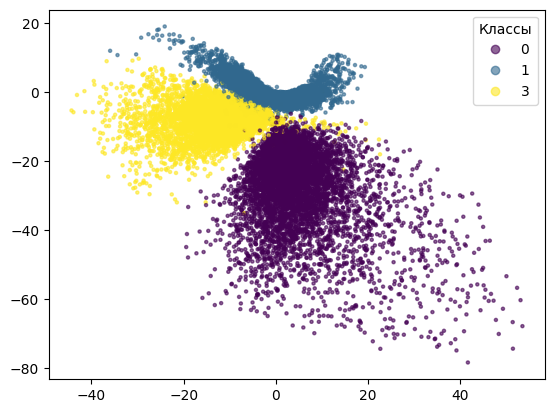

147/147 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0288
Epoch 10/10
144/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0287________________________
*** ЭПОХА: 10, loss: 0.028588980436325073 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


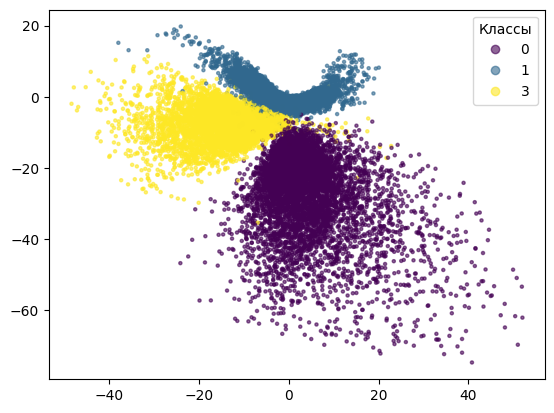

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0286

Итоговая ошибка MSE на 10-й эпохе: 0.02859
Успех! Требуемое условие задания (MSE < 0.034) полностью выполнено.


In [ ]:

print("Старт обучения свёрточного автокодировщика...")

history = autoencoder.fit(
    X_train, X_train,
    epochs=10,                      # Ровно 10 эпох по условию
    batch_size=128,
    shuffle=True,
    callbacks=[ae_callback]         # Логирование и построение графиков в конце каждой эпохи
)

# Финальная проверка качества
final_mse = history.history['loss'][-1]

print(f"Итоговая ошибка MSE на 10-й эпохе: {final_mse:.5f}")
if final_mse < 0.034:
    print("Успех! Требуемое условие задания (MSE < 0.034) полностью выполнено.")
else:
    print("Внимание: Порог не пройден. Попробуйте перезапустить ячейку.")
